# **Тема 6. Сплайны**

In [ ]:
#Метод монотонной прогонки

import numpy as np
from math import log

np.set_printoptions(precision=6, suppress=True)


def y_true(x):
    return x**2 + log(x) - 4

def y_true_d1(x):
    return 2*x + 1/x


a, b = 1.5, 2.0
h = 0.05
n_segments = int((b - a) / h)
print(f"Шаг h: {h}")
print(f"Количество сегментов: {n_segments}")

xs = np.array([a + i * h for i in range(n_segments + 1)])
ys = np.array([y_true(x) for x in xs])
N = len(xs)  # N = n_segments + 1
print(f"Точки x: {xs}")
print(f"Значения y: {ys}")
print(f"Количество точек N: {N}")

# краевые условия
m0 = y_true_d1(xs[0])   # S'(x0) = y'(x0)
mN = y_true_d1(xs[-1])  # S'(xN) = y'(xN)
print(f"\nКраевые производные: m0 = {m0:.6f}, mN = {mN:.6f}")

# Количество неизвестных наклонов (внутренние точки): m1, ..., m_{N-2}
N_eq = n_segments - 1  # = N - 2
if N_eq <= 0:
    raise ValueError("Слишком мало точек для построения сплайна!")

# Коэффициенты в уравнениях системы: A[i] * m_{i-1} + B[i] * m_i + C[i] * m_{i+1} = F[i]
A = np.zeros(N_eq)
B = np.zeros(N_eq)
C = np.zeros(N_eq)
F = np.zeros(N_eq)

# Так как h постоянный, lambda = mu = h / (h + h) = 0.5
lam = 0.5
mu = 0.5

# Первое уравнение (для m1)
# mu * m0 + 2 * m1 + lam * m2 = 3 * ( lam*(y2 - y1)/h + mu*(y1 - y0)/h )
A[0] = 0.0  # m0 не входит в неизвестные, переносим его в правую часть
B[0] = 2.0
C[0] = lam
F[0] = 3 * (lam * (ys[2] - ys[1]) / h + mu * (ys[1] - ys[0]) / h) - mu * m0

# Внутренние уравнения (для m2, ..., m_{N-2})
for i in range(1, N_eq - 1):
    A[i] = mu
    B[i] = 2.0
    C[i] = lam
    F[i] = 3 * (lam * (ys[i+2] - ys[i+1]) / h + mu * (ys[i+1] - ys[i]) / h)

# Последнее уравнение (для m_{N-2})
# mu * m_{N-3} + 2 * m_{N-2} + lam * m_{N-1} = ...
# Но m_{N-1} = mN — известно, переносим в правую часть
A[N_eq - 1] = mu
B[N_eq - 1] = 2.0
C[N_eq - 1] = 0.0
F[N_eq - 1] = 3 * (lam * (ys[-1] - ys[-2]) / h + mu * (ys[-2] - ys[-3]) / h) - lam * mN

print("\nМассивы коэффициентов для метода прогонки:")
print(f"A: {A}")
print(f"B: {B}")
print(f"C: {C}")
print(f"F: {F}")


alpha = np.zeros(N_eq)
beta = np.zeros(N_eq)


alpha[0] = -C[0] / B[0]
beta[0] = F[0] / B[0]

for i in range(1, N_eq):
    denom = B[i] + A[i] * alpha[i-1]
    alpha[i] = -C[i] / denom
    beta[i] = (F[i] - A[i] * beta[i-1]) / denom

m_internal = np.zeros(N_eq)
m_internal[-1] = beta[-1]
for i in range(N_eq - 2, -1, -1):
    m_internal[i] = alpha[i] * m_internal[i+1] + beta[i]

m = np.zeros(N)
m[0] = m0
m[-1] = mN
m[1:-1] = m_internal

print("\nПолный вектор наклонов (первая производная в узлах):")
print(f"m = {m}")

Шаг h: 0.05
Количество сегментов: 10
Точки x: [1.5  1.55 1.6  1.65 1.7  1.75 1.8  1.85 1.9  1.95 2.  ]
Значения y: [-1.344535 -1.159245 -0.969996 -0.776725 -0.579372 -0.377884 -0.172213
  0.037686  0.251854  0.470329  0.693147]
Количество точек N: 11

Краевые производные: m0 = 3.666667, mN = 4.500000

Массивы коэффициентов для метода прогонки:
A: [0.  0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
B: [2. 2. 2. 2. 2. 2. 2. 2. 2.]
C: [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0. ]
F: [ 9.402822 11.475611 11.718739 11.965215 12.214752 12.467096 12.722017
 12.979312 10.988799]

Полный вектор наклонов (первая производная в узлах):
m = [3.666667 3.745161 3.825    3.906061 3.988235 4.071429 4.155556 4.240541
 4.326316 4.41282  4.5     ]


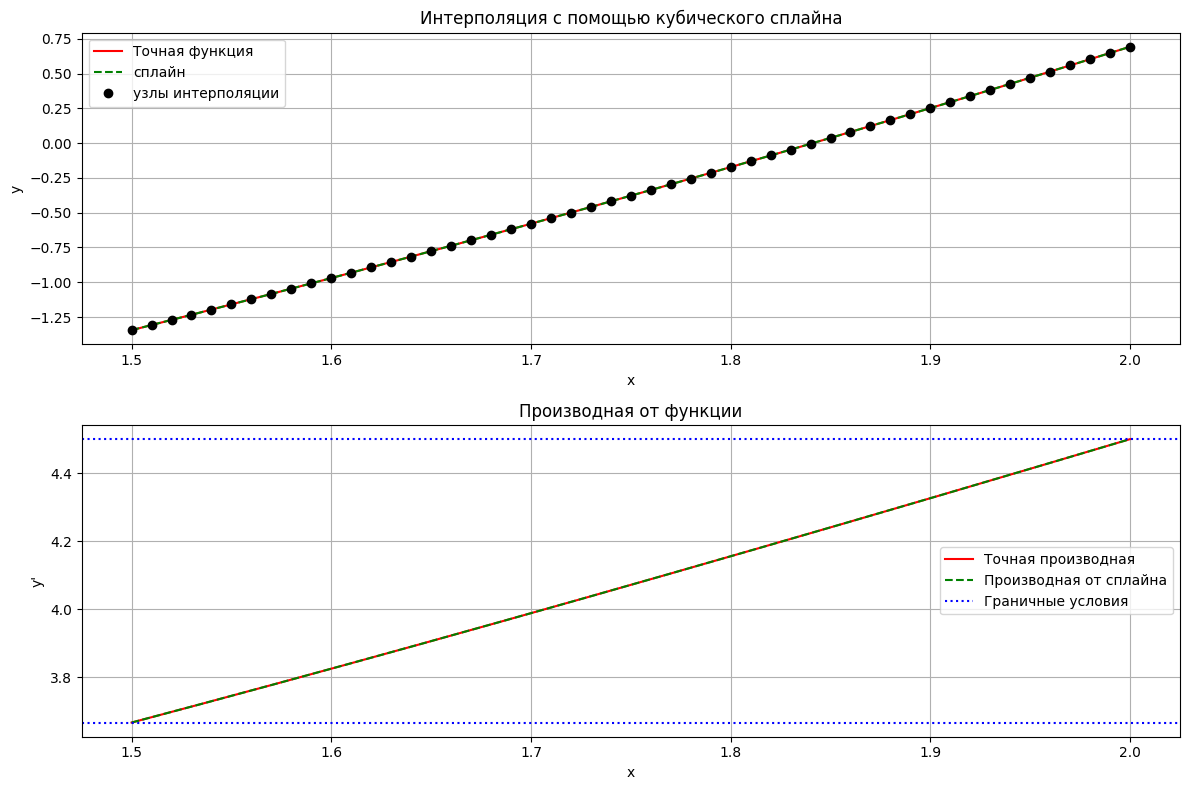

Максимальная погрешность функции: 3.07e-11
Максимальная погрешность производной: 9.22e-09
Количество отрезков: 50
Шаг: 0.01


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**2 + np.log(x) - 4

def df(x):
    return 2*x + 1/x

a, b = 1.5, 2.0
h = 0.01
n = int((b - a) / h)

x_nodes = np.linspace(a, b, n + 1)
y_nodes = f(x_nodes)

df_a = df(a)
df_b = df(b)


def build_spline_type1(x, y, m0, mN):
    N = len(x) - 1
    n = N - 1

    A = np.zeros((n, n))
    np.fill_diagonal(A, 4)
    np.fill_diagonal(A[1:], 1)
    np.fill_diagonal(A[:, 1:], 1)

    rhs = np.zeros(n)
    for j in range(n):
        i = j + 1
        rhs[j] = (3 / h) * (y[i+1] - y[i-1])


    rhs[0] -= m0
    rhs[-1] -= mN

    m_internal = np.linalg.solve(A, rhs)


    m = np.zeros(N + 1)
    m[0] = m0
    m[1:-1] = m_internal
    m[-1] = mN


    a_coeffs = np.zeros(N)
    b_coeffs = np.zeros(N)
    c_coeffs = m[:-1]
    d_coeffs = np.zeros(N)
    e_coeffs = np.zeros(N)

    for i in range(N):
        h_i = x[i+1] - x[i]
        delta_y = y[i+1] - y[i]
        d_coeffs[i] = (3 * delta_y / h_i - 2 * m[i] - m[i+1]) / h_i
        e_coeffs[i] = (m[i] + m[i+1] - 2 * (y[i+1] - y[i]) / h) / (h**2)

    return y[:-1], m[:-1], d_coeffs, e_coeffs


def evaluate_spline(x_eval, x_nodes, coeffs):
    y_nodes, m_coeffs, a_coeffs, b_coeffs = coeffs
    n = len(x_nodes) - 1
    y_eval = np.zeros_like(x_eval)

    for k, xi in enumerate(x_eval):
        if xi == x_nodes[-1]:
            i = n - 1
        else:
            i = np.searchsorted(x_nodes, xi) - 1
            i = max(0, min(i, n - 1))

        t = xi - x_nodes[i]
        y_eval[k] = y_nodes[i] + m_coeffs[i]*t + a_coeffs[i]*t**2 + b_coeffs[i]*t**3

    return y_eval



def spline_derivative(x, x_nodes, coeffs):
    y_nodes, m_coeffs, a_coeffs, b_coeffs = coeffs
    n = len(x_nodes) - 1

    result = np.zeros_like(x)
    for i in range(len(x)):
        idx = np.searchsorted(x_nodes, x[i]) - 1
        idx = max(0, min(idx, n - 1))

        dx = x[i] - x_nodes[idx]
        result[i] = m_coeffs[idx] + 2*a_coeffs[idx]*dx + 3*b_coeffs[idx]*dx**2

    return result


coeffs = build_spline_type1(x_nodes, y_nodes, df_a, df_b)


x_dense = np.linspace(a, b, 200)
y_exact = f(x_dense)
y_spline = evaluate_spline(x_dense, x_nodes, coeffs)
df_spline = spline_derivative(x_dense, x_nodes, coeffs)
df_exact = df(x_dense)


plt.figure(figsize=(12, 8))


plt.subplot(2, 1, 1)
plt.plot(x_dense, y_exact, 'r-', label='Точная функция')
plt.plot(x_dense, y_spline, 'g--', label='сплайн')
plt.plot(x_nodes, y_nodes, 'ko', label='узлы интерполяции')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Интерполяция с помощью кубического сплайна')
plt.grid(True)


plt.subplot(2, 1, 2)
plt.plot(x_dense, df_exact, 'r-', label='Точная производная')
plt.plot(x_dense, df_spline, 'g--', label='Производная от сплайна')
plt.axhline(y=df_a, color='b', linestyle=':', label='Граничные условия')
plt.axhline(y=df_b, color='b', linestyle=':')
plt.xlabel('x')
plt.ylabel("y'")
plt.legend()
plt.title('Производная от функции')
plt.grid(True)

plt.tight_layout()
plt.show()

error_func = np.max(np.abs(y_spline - y_exact))
error_deriv = np.max(np.abs(df_spline - df_exact))

print(f"Максимальная погрешность функции: {error_func:.2e}")
print(f"Максимальная погрешность производной: {error_deriv:.2e}")
print(f"Количество отрезков: {n}")
print(f"Шаг: {h}")
